# More pandas

In [1]:
import numpy as np
import pandas as pd

In [2]:
sampledata = pd.DataFrame(np.arange(8).reshape((2,4)), index=['cantaloupe','banana'], columns=['d','a','b','c'])

sampledata

,d,a,b,c
cantaloupe,0,1,2,3
banana,4,5,6,7


### using sort_index

In [3]:
sampledata.sort_index()

,d,a,b,c
banana,4,5,6,7
cantaloupe,0,1,2,3


In [4]:
sampledata.sort_index(axis='columns')

,a,b,c,d
cantaloupe,1,2,3,0
banana,5,6,7,4


### using rank

In [5]:
rowdata = {'col1': [414, 651], 'col2': [715, 612]}
areacodes = pd.DataFrame(rowdata, index = ['WI', 'MN'])
areacodes['col3'] = [262, 218]
areacodes

,col1,col2,col3
WI,414,715,262
MN,651,612,218


In [6]:
areacodes.rank(axis="columns")

# for row WI,  rank is col3, col1, col2
# for row MN,  rank is col3, col2, col2

,col1,col2,col3
WI,2.0,3.0,1.0
MN,3.0,2.0,1.0


In [7]:
areacodes.rank(axis='rows')

# for col1, rank is WI first, MN second, etc...

,col1,col2,col3
WI,1.0,2.0,2.0
MN,2.0,1.0,1.0


In [8]:
veg = areacodes
veg.columns = ['beets', 'carrots', 'cabbage']  # how many bushels of vegetables?
veg

,beets,carrots,cabbage
WI,414,715,262
MN,651,612,218


In [9]:
# back to rank:

veg['beets'].rank()

WI    1.0
MN    2.0
Name: beets, dtype: float64

In [10]:
veg_rank = veg[['beets', 'carrots']].rank(axis='columns')
veg_rank.columns = ['top beets producer', 'top carrots producer']
veg_rank

,top beets producer,top carrots producer
WI,1.0,2.0
MN,2.0,1.0


In [11]:
## merging DataFrames

In [12]:
veg

,beets,carrots,cabbage
WI,414,715,262
MN,651,612,218


In [13]:
veg_composite = pd.merge(veg, veg_rank, on = veg.index)
veg_composite

# merging veg (original) and veg_rank (with the ranking) into one DataFrame
# the "on" parameter is used to specify a column that is being joined on
# in this example, we're using veg.index as the column to join on
# the reult: is that veg.index gets pulled into a new column

,key_0,beets,carrots,cabbage,top beets producer,top carrots producer
0,WI,414,715,262,1.0,2.0
1,MN,651,612,218,2.0,1.0


In [14]:
# the above is working, but it smooshes the index into a new key column

# the below version is a little more elegant in preserving the index names

In [15]:
veg_composite2 = pd.merge(veg, veg_rank, left_index = True, right_index = True)   # not using the parameter "on"
veg_composite2

,beets,carrots,cabbage,top beets producer,top carrots producer
WI,414,715,262,1.0,2.0
MN,651,612,218,2.0,1.0


# Working with matplotlib

In [16]:
import matplotlib.pyplot as plt

In [17]:
# if we're going to create a graph out of veg_composite2 ...
# ... what should it look like?
# ... using what values?

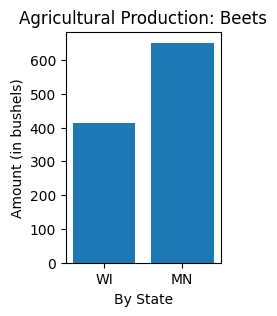

In [18]:
# bar graph
# show comparison of WI and MN, could be two different colors
# numbers to compare on y axis, and states on x axis
# just the beets, carrots and cabbage but not the top producers

plt.figure(figsize=(2,3))  # in inches, size of the returned figure

plt.title("Agricultural Production: Beets")
plt.xlabel("By State")
plt.ylabel("Amount (in bushels)")

plt.bar(
    veg_composite2.index, 
    veg_composite2['beets']
)

plt.show()     # .show() is the print() of matplotlib

In [19]:
# a line chart using plot() does not make sense here!

# plt.plot(
#     veg_composite2.index, 
#     veg_composite2['beets']
# )

# plt.show()

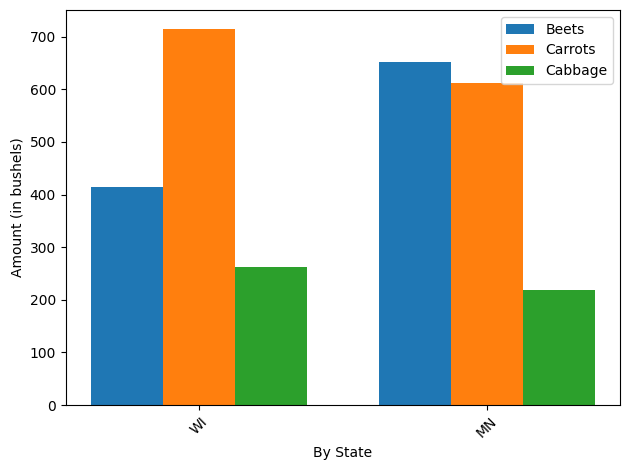

In [26]:
x = np.arange(len(veg_composite2.index))  # the length of the index for our DataFrame, which is [0, 1]
width = .25

fig, ax = plt.subplots()   # helpful where you're graphing multiple values on the same chart

ax.bar(x - width, veg_composite2['beets'], width, label='Beets')
ax.bar(x, veg_composite2['carrots'], width, label='Carrots')
ax.bar(x + width, veg_composite2['cabbage'], width, label='Cabbage')

ax.set_xlabel("By State")
ax.set_ylabel("Amount (in bushels)")
ax.set_xticks(x)
ax.set_xticklabels(veg_composite2.index, rotation=45)
ax.legend()

plt.tight_layout()
plt.savefig('agricultural_data.png')
plt.show()

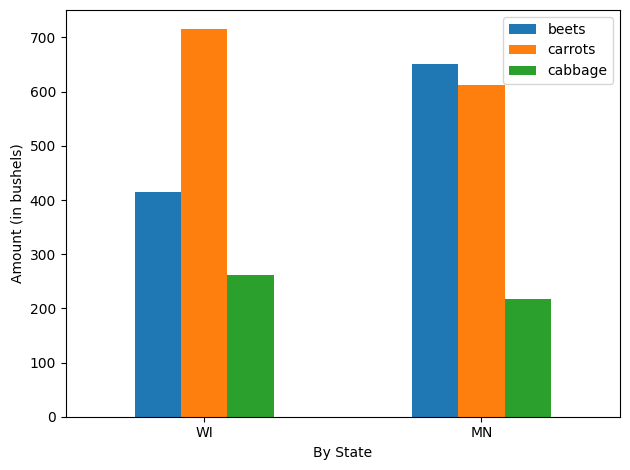

In [24]:
# bonus alternative

# Ok, here's actually a shorter way of doing the same thing, using the .plot method
# (but it wouldn't have given me the opportunity to talk about using subplots!)

veg_composite2[['beets', 'carrots', 'cabbage']].plot(kind='bar', rot=0)

plt.xlabel("By State")
plt.ylabel("Amount (in bushels)")
plt.tight_layout()
plt.show()